In [46]:
import pandas as pd
import numpy as np
import torch
import torch_geometric
from torch_geometric.data import HeteroData
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [47]:
# Load all data
commit_features = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\derived\preprocessing_final\final_commit_level_features.csv")
commit_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\commit_info.csv")
issue_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\issue_info_v3.csv")
pr_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\pull_request_info_v3.csv")
release_tag_info = pd.read_csv(r"C:\Users\User\OneDrive\thesis\ICVul_pp\src\release_tag_info_v3.csv")

print("Commit features:", commit_features.shape)
print("Commit info:", commit_info.shape)
print("Issue info:", issue_info.shape)
print("PR info:", pr_info.shape)
print("Release tag info:", release_tag_info.shape)

Commit features: (8773, 16)
Commit info: (8796, 21)
Issue info: (691670, 10)
PR info: (469952, 13)
Release tag info: (6617, 8)


In [48]:
# Configuration: select MODE {1,2,3,4}
MODE = 3
ENGINEERED_ISSUE_NODE_FEATURES= [
    'issue_age_median', 'issue_close_rate_180d'
]
ENGINEERED_PR_NODE_FEATURES = [
    'pr_age_median', 'pr_merge_or_close_rate_180d'
]
ENGINEERED_TAG_NODE_FEATURES = [
    'time_since_last_tag', 'tags_last_180d'
]
ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES = [
    'issue_open_at_anchor'
]
ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES = [
    'pr_count'
]
ENGINEERED_COMMIT_TO_TAG_EDGE_FEATURES = [
    'has_release_pressure_180d'
]
ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES = [
    'pr_to_issue_open_ratio_90d', 'has_issue_pr_gap'
]
ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES = [
    'activity_since_last_tag'
]
    
EXCLUDE_PATTERNS = [
    'hash', 'repo', 'url', 'id', 'number', 'node_id', 'fc_hash', 'vcc_hash', 
    'matched_anchor', 'window_since', 'window_until', 'commit_datetime',
    'created_at', 'closed_at', 'merged_at', 'updated_at', 'title', 'body'
]
target_hash = "a5a51ad3a1200e2e5ef46c140bab717422e41ca2"
    
print(f"\nChosen commit: {target_hash}")
commit_row = commit_features[commit_features["hash"] == target_hash]
commit_row.head()


Chosen commit: a5a51ad3a1200e2e5ef46c140bab717422e41ca2


,hash,repo_url,commit_datetime,y_binary,issue_age_median,pr_age_median,time_since_last_tag,tags_last_180d,pr_count,issue_open_at_anchor,activity_since_last_tag,pr_to_issue_open_ratio_90d,issue_close_rate_180d,pr_merge_or_close_rate_180d,has_release_pressure_180d,has_issue_pr_gap
8081,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow,2018-04-30 13:59:23+00:00,1,1064.0,1068.0,1058.0,0.0,1234.0,176.0,6.192839,0.664022,0.373204,0.752776,0,1


In [49]:
# Helper functions for graph building

def detect_id_column(df, candidates):
    """Detect the best ID column from candidates list."""
    for col in candidates:
        if col in df.columns:
            return col
    print(f"⚠ No ID column found from {candidates}, using index as ID")
    return None

def extract_raw_numeric_features(df, exclude_patterns=EXCLUDE_PATTERNS):
    """Extract numeric features from raw dataframe, excluding identifier-like columns."""
    if df.empty:
        return np.zeros((len(df), 1), dtype="float32"), []
    
    numeric_cols = df.select_dtypes(include=[np.number, bool]).columns.tolist()
    filtered_cols = [
        col for col in numeric_cols 
        if not any(pat in col.lower() for pat in exclude_patterns)
    ]
    
    if not filtered_cols:
        return np.zeros((len(df), 1), dtype="float32"), []
    
    return df[filtered_cols].fillna(0).values.astype("float32"), filtered_cols

def deduplicate_entities(df, id_col):
    """Deduplicate entities by ID column, return unique df and id-to-index mapping."""
    if id_col is None:
        df_unique = df.copy().reset_index(drop=True)
        id_to_idx = {i: i for i in range(len(df_unique))}
    else:
        df_unique = df.drop_duplicates(subset=[id_col]).reset_index(drop=True)
        id_to_idx = {row[id_col]: i for i, row in df_unique.iterrows()}
    return df_unique, id_to_idx

def build_pr_issue_edges(pr_df_unique, pr_id_col, issue_df_unique, issue_id_col):
    """Build PR-Issue edges via direct column match or regex extraction."""
    pr_issue_src, pr_issue_dst = [], []
    issue_id_to_idx = {row[issue_id_col]: i for i, row in issue_df_unique.iterrows()} if issue_id_col else {}
    
    # Strategy A: direct column match
    link_cols = ['issue_id', 'linked_issue_id', 'closing_issue_id', 'issue_number']
    matched_col = None
    for col in link_cols:
        if col in pr_df_unique.columns:
            matched_col = col
            break
    
    if matched_col and issue_id_col:
        for pr_idx, row in pr_df_unique.iterrows():
            issue_id = row[matched_col]
            if pd.notna(issue_id) and issue_id in issue_id_to_idx:
                pr_issue_src.append(pr_idx)
                pr_issue_dst.append(issue_id_to_idx[issue_id])
        if pr_issue_src:
            print(f"✓ Built PR-Issue edges via column '{matched_col}': {len(pr_issue_src)} edges")
            return torch.tensor([pr_issue_src, pr_issue_dst], dtype=torch.long)
    
    # Strategy B: regex extraction from text
    import re
    text_cols = [c for c in ['body', 'title'] if c in pr_df_unique.columns]
    if text_cols and issue_id_col and issue_id_col in ['number', 'issue_number']:
        issue_numbers = set(issue_df_unique[issue_id_col].dropna().astype(int))
        for pr_idx, row in pr_df_unique.iterrows():
            text = " ".join([str(row[c]) for c in text_cols if pd.notna(row[c])])
            matches = re.findall(r'#(\d+)', text)
            for m in matches:
                num = int(m)
                if num in issue_numbers and num in issue_id_to_idx:
                    pr_issue_src.append(pr_idx)
                    pr_issue_dst.append(issue_id_to_idx[num])
        if pr_issue_src:
            print(f"✓ Built PR-Issue edges via regex extraction: {len(pr_issue_src)} edges")
            return torch.tensor([pr_issue_src, pr_issue_dst], dtype=torch.long)
    
    print("⚠ Could not build PR-Issue edges (no suitable columns or matches)")
    return torch.zeros((2, 0), dtype=torch.long)

def build_temporal_edges(df, timestamp_candidates):
    """Build temporal chain edges for entities based on timestamp."""
    for ts_col in timestamp_candidates:
        if ts_col in df.columns:
            df_copy = df.copy()
            df_copy['_ts'] = pd.to_datetime(df_copy[ts_col], errors='coerce', utc=True)
            df_valid = df_copy.dropna(subset=['_ts']).sort_values('_ts').reset_index(drop=True)
            if len(df_valid) > 1:
                src = list(range(len(df_valid) - 1))
                dst = list(range(1, len(df_valid)))
                # Map back to original indices
                orig_indices = df_valid.index.tolist()
                return torch.tensor([src, dst], dtype=torch.long), orig_indices
            break
    return torch.zeros((2, 0), dtype=torch.long), []


In [50]:
def build_graph_for_commit(target_hash, mode):
    """Build HeteroData graph for one commit in specified feature mode."""
    
    # Filter data for target commit
    commit_data = commit_features[commit_features["hash"] == target_hash]
    if commit_data.empty:
        raise ValueError(f"Commit {target_hash} not found in features")
    
    linked_issues = issue_info[
        (issue_info["fc_hash"] == target_hash) | (issue_info["vcc_hash"] == target_hash)
    ]
    linked_prs = pr_info[
        (pr_info["fc_hash"] == target_hash) | (pr_info["vcc_hash"] == target_hash)
    ]
    linked_tags = release_tag_info[
        (release_tag_info["fc_hash"] == target_hash) | (release_tag_info["vcc_hash"] == target_hash)
    ]
    
    # Deduplicate entities
    issue_id_col = detect_id_column(linked_issues, ['issue_id', 'id', 'number', 'issue_number'])
    pr_id_col = detect_id_column(linked_prs, ['pull_request_id', 'pr_id', 'id', 'number', 'pull_request_number'])
    tag_id_col = detect_id_column(linked_tags, ['tag_name', 'name', 'tag', 'release_tag', 'id'])
    
    issues_unique, issue_id_to_idx = deduplicate_entities(linked_issues, issue_id_col)
    prs_unique, pr_id_to_idx = deduplicate_entities(linked_prs, pr_id_col)
    tags_unique, tag_id_to_idx = deduplicate_entities(linked_tags, tag_id_col)
    
    num_issues = len(issues_unique)
    num_prs = len(prs_unique)
    num_tags = len(tags_unique)
    
    # Extract label
    y_commit = commit_data["y_binary"].values if "y_binary" in commit_data.columns else np.array([0])
    
    # Build features based on MODE
    feature_info = {"mode": mode, "commit": [], "issue": [], "pull_request": [], "release_tag": []}
    edge_features = {}  # Initialize edge_features dictionary
    
    if mode == 1:  # Only raw data
        commit_raw = commit_info[commit_info["hash"] == target_hash]
        if not commit_raw.empty:
            X_commit, commit_cols = extract_raw_numeric_features(commit_raw)
        else:
            X_commit, commit_cols = np.zeros((1, 1), dtype="float32"), []
        X_issue, issue_cols = extract_raw_numeric_features(issues_unique)
        X_pr, pr_cols = extract_raw_numeric_features(prs_unique)
        X_tag, tag_cols = extract_raw_numeric_features(tags_unique)
        feature_info["commit"] = commit_cols
        feature_info["issue"] = issue_cols
        feature_info["pull_request"] = pr_cols
        feature_info["release_tag"] = tag_cols
        
    elif mode == 2:  # Only engineered - single nodes for each entity type
        # Extract commit node features (all engineered features at commit level)
        commit_raw = commit_info[commit_info["hash"] == target_hash]
        if not commit_raw.empty:
            X_commit, commit_cols = extract_raw_numeric_features(commit_raw)
        else:
            X_commit, commit_cols = np.zeros((1, 1), dtype="float32"), []
        
        # For MODE 2, create single nodes for each entity type
        # Node features come from commit-level engineered features
        if num_issues > 0:
            issue_features = commit_data[ENGINEERED_ISSUE_NODE_FEATURES].fillna(0).values.astype("float32")
            X_issue = issue_features  # Single node, shape (1, num_features)
        else:
            X_issue = np.zeros((0, len(ENGINEERED_ISSUE_NODE_FEATURES)), dtype="float32")
            
        if num_prs > 0:
            pr_features = commit_data[ENGINEERED_PR_NODE_FEATURES].fillna(0).values.astype("float32")
            X_pr = pr_features  # Single node, shape (1, num_features)
        else:
            X_pr = np.zeros((0, len(ENGINEERED_PR_NODE_FEATURES)), dtype="float32")
            
        if num_tags > 0:
            tag_features = commit_data[ENGINEERED_TAG_NODE_FEATURES].fillna(0).values.astype("float32")
            X_tag = tag_features  # Single node, shape (1, num_features)
        else:
            X_tag = np.zeros((0, len(ENGINEERED_TAG_NODE_FEATURES)), dtype="float32")
        
        feature_info["commit"] = commit_cols
        feature_info["issue"] = ENGINEERED_ISSUE_NODE_FEATURES
        feature_info["pull_request"] = ENGINEERED_PR_NODE_FEATURES
        feature_info["release_tag"] = ENGINEERED_TAG_NODE_FEATURES
        
        # Store edge features for later attachment
        edge_features = {
            "commit_to_issue": commit_data[ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 else None,
            "commit_to_pr": commit_data[ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_prs > 0 else None,
            "commit_to_tag": commit_data[ENGINEERED_COMMIT_TO_TAG_EDGE_FEATURES].fillna(0).values.astype("float32") if num_tags > 0 else None,
            "issue_to_pr": commit_data[ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 and num_prs > 0 else None,
            "tag_to_pr": commit_data[ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_tags > 0 and num_prs > 0 else None,
            "tag_to_issue": commit_data[ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_tags > 0 and num_issues > 0 else None,
        }
        feature_info["edge_features"] = {
            "commit_to_issue": ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES,
            "commit_to_pr": ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES,
            "commit_to_tag": ENGINEERED_COMMIT_TO_TAG_EDGE_FEATURES,
            "issue_to_pr": ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES,
            "tag_to_pr": ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES,
            "tag_to_issue": ENGINEERED_TAG_TO_PR_ISSUE_EDGE_FEATURES,
        }

    elif mode == 3:  # Hybrid: tags as raw (multiple nodes), issues/PRs as engineered (single nodes)
        # Extract commit node features (raw)
        commit_raw = commit_info[commit_info["hash"] == target_hash]
        if not commit_raw.empty:
            X_commit, commit_cols = extract_raw_numeric_features(commit_raw)
        else:
            X_commit, commit_cols = np.zeros((1, 1), dtype="float32"), []
        
        # Issues: single node with engineered features
        if num_issues > 0:
            issue_features = commit_data[ENGINEERED_ISSUE_NODE_FEATURES].fillna(0).values.astype("float32")
            X_issue = issue_features  # Single node, shape (1, num_features)
        else:
            X_issue = np.zeros((0, len(ENGINEERED_ISSUE_NODE_FEATURES)), dtype="float32")
        
        # PRs: single node with engineered features
        if num_prs > 0:
            pr_features = commit_data[ENGINEERED_PR_NODE_FEATURES].fillna(0).values.astype("float32")
            X_pr = pr_features  # Single node, shape (1, num_features)
        else:
            X_pr = np.zeros((0, len(ENGINEERED_PR_NODE_FEATURES)), dtype="float32")
        
        # Tags: multiple nodes with raw features
        X_tag, tag_cols = extract_raw_numeric_features(tags_unique)
        
        feature_info["commit"] = commit_cols
        feature_info["issue"] = ENGINEERED_ISSUE_NODE_FEATURES
        feature_info["pull_request"] = ENGINEERED_PR_NODE_FEATURES
        feature_info["release_tag"] = tag_cols
        
        # Store edge features for edges involving single nodes (issue/PR)
        edge_features = {
            "commit_to_issue": commit_data[ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 else None,
            "commit_to_pr": commit_data[ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_prs > 0 else None,
            "issue_to_pr": commit_data[ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES].fillna(0).values.astype("float32") if num_issues > 0 and num_prs > 0 else None,
        }
        feature_info["edge_features"] = {
            "commit_to_issue": ENGINEERED_COMMIT_TO_ISSUE_EDGE_FEATURES,
            "commit_to_pr": ENGINEERED_COMMIT_TO_PR_EDGE_FEATURES,
            "issue_to_pr": ENGINEERED_ISSUE_TO_PR_EDGE_FEATURES,
        }

    else:
        raise ValueError(f"Invalid mode: {mode}")
    
    # Build HeteroData
    data = HeteroData()
    data["commit"].x = torch.tensor(X_commit, dtype=torch.float32)
    data["commit"].y = torch.tensor(y_commit, dtype=torch.long)
    
    # Add entity nodes
    if num_issues > 0:
        data["issue"].x = torch.tensor(X_issue, dtype=torch.float32)
    if num_prs > 0:
        data["pull_request"].x = torch.tensor(X_pr, dtype=torch.float32)
    if num_tags > 0:
        data["release_tag"].x = torch.tensor(X_tag, dtype=torch.float32)
    
    # Build commit-entity edges
    if mode == 2:  # MODE 2: single nodes, single edges
        if num_issues > 0:
            commit_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)  # Single edge: commit[0] -> issue[0]
            data["commit", "linked_issue", "issue"].edge_index = commit_issue_edge
            data["issue", "issue_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_prs > 0:
            commit_pr_edge = torch.tensor([[0], [0]], dtype=torch.long)  # Single edge: commit[0] -> pr[0]
            data["commit", "linked_pr", "pull_request"].edge_index = commit_pr_edge
            data["pull_request", "pr_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0:
            commit_tag_edge = torch.tensor([[0], [0]], dtype=torch.long)  # Single edge: commit[0] -> tag[0]
            data["commit", "has_release_tag", "release_tag"].edge_index = commit_tag_edge
            data["release_tag", "tag_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        # Build PR-Issue edge for MODE 2
        if num_prs > 0 and num_issues > 0:
            pr_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)  # Single edge: pr[0] -> issue[0]
            data["pull_request", "references_issue", "issue"].edge_index = pr_issue_edge
            data["issue", "referenced_by_pr", "pull_request"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        # Build Tag-PR and Tag-Issue edges for MODE 2
        if num_tags > 0 and num_prs > 0:
            tag_pr_edge = torch.tensor([[0], [0]], dtype=torch.long)  # Single edge: tag[0] -> pr[0]
            data["release_tag", "affects_pr", "pull_request"].edge_index = tag_pr_edge
            data["pull_request", "in_release", "release_tag"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        if num_tags > 0 and num_issues > 0:
            tag_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)  # Single edge: tag[0] -> issue[0]
            data["release_tag", "affects_issue", "issue"].edge_index = tag_issue_edge
            data["issue", "in_release", "release_tag"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
    
    elif mode == 3:  # MODE 3: issues/PRs as single nodes, tags as multiple nodes
        # Commit -> Issue: single edge
        if num_issues > 0:
            commit_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            data["commit", "linked_issue", "issue"].edge_index = commit_issue_edge
            data["issue", "issue_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        # Commit -> PR: single edge
        if num_prs > 0:
            commit_pr_edge = torch.tensor([[0], [0]], dtype=torch.long)
            data["commit", "linked_pr", "pull_request"].edge_index = commit_pr_edge
            data["pull_request", "pr_of", "commit"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        # Commit -> Tags: multiple edges (one per tag)
        if num_tags > 0:
            commit_tag_edge = torch.stack([
                torch.zeros(num_tags, dtype=torch.long),
                torch.arange(num_tags, dtype=torch.long)
            ])
            data["commit", "has_release_tag", "release_tag"].edge_index = commit_tag_edge
            data["release_tag", "tag_of", "commit"].edge_index = torch.stack([commit_tag_edge[1], commit_tag_edge[0]])
        
        # PR -> Issue: single edge
        if num_prs > 0 and num_issues > 0:
            pr_issue_edge = torch.tensor([[0], [0]], dtype=torch.long)
            data["pull_request", "references_issue", "issue"].edge_index = pr_issue_edge
            data["issue", "referenced_by_pr", "pull_request"].edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        
        # Tag -> PR: multiple edges (each tag -> single PR node)
        if num_tags > 0 and num_prs > 0:
            tag_pr_edge = torch.stack([
                torch.arange(num_tags, dtype=torch.long),  # All tags
                torch.zeros(num_tags, dtype=torch.long)    # -> single PR node
            ])
            data["release_tag", "affects_pr", "pull_request"].edge_index = tag_pr_edge
            data["pull_request", "in_release", "release_tag"].edge_index = torch.stack([tag_pr_edge[1], tag_pr_edge[0]])
        
        # Tag -> Issue: multiple edges (each tag -> single issue node)
        if num_tags > 0 and num_issues > 0:
            tag_issue_edge = torch.stack([
                torch.arange(num_tags, dtype=torch.long),  # All tags
                torch.zeros(num_tags, dtype=torch.long)    # -> single issue node
            ])
            data["release_tag", "affects_issue", "issue"].edge_index = tag_issue_edge
            data["issue", "in_release", "release_tag"].edge_index = torch.stack([tag_issue_edge[1], tag_issue_edge[0]])
    
    else:  # MODE 1, 4: all multiple nodes, multiple edges
        if num_issues > 0:
            commit_issue_edge = torch.stack([
                torch.zeros(num_issues, dtype=torch.long),
                torch.arange(num_issues, dtype=torch.long)
            ])
            data["commit", "linked_issue", "issue"].edge_index = commit_issue_edge
            data["issue", "issue_of", "commit"].edge_index = torch.stack([commit_issue_edge[1], commit_issue_edge[0]])
        
        if num_prs > 0:
            commit_pr_edge = torch.stack([
                torch.zeros(num_prs, dtype=torch.long),
                torch.arange(num_prs, dtype=torch.long)
            ])
            data["commit", "linked_pr", "pull_request"].edge_index = commit_pr_edge
            data["pull_request", "pr_of", "commit"].edge_index = torch.stack([commit_pr_edge[1], commit_pr_edge[0]])
        
        if num_tags > 0:
            commit_tag_edge = torch.stack([
                torch.zeros(num_tags, dtype=torch.long),
                torch.arange(num_tags, dtype=torch.long)
            ])
            data["commit", "has_release_tag", "release_tag"].edge_index = commit_tag_edge
            data["release_tag", "tag_of", "commit"].edge_index = torch.stack([commit_tag_edge[1], commit_tag_edge[0]])
        
        # Build PR-Issue edges
        if num_prs > 0 and num_issues > 0:
            pr_issue_edge = build_pr_issue_edges(prs_unique, pr_id_col, issues_unique, issue_id_col)
            if pr_issue_edge.shape[1] > 0:
                data["pull_request", "references_issue", "issue"].edge_index = pr_issue_edge
                data["issue", "referenced_by_pr", "pull_request"].edge_index = torch.stack([pr_issue_edge[1], pr_issue_edge[0]])
    
    # Attach edge features for MODE 2
    if mode == 2 and edge_features:
        # Commit to Issue edges - single edge with features
        if num_issues > 0 and "commit_to_issue" in edge_features and edge_features["commit_to_issue"] is not None:
            data["commit", "linked_issue", "issue"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
            data["issue", "issue_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
        
        # Commit to PR edges - single edge with features
        if num_prs > 0 and "commit_to_pr" in edge_features and edge_features["commit_to_pr"] is not None:
            data["commit", "linked_pr", "pull_request"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
            data["pull_request", "pr_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
        
        # Commit to Tag edges - single edge with features
        if num_tags > 0 and "commit_to_tag" in edge_features and edge_features["commit_to_tag"] is not None:
            data["commit", "has_release_tag", "release_tag"].edge_attr = torch.tensor(edge_features["commit_to_tag"], dtype=torch.float32)
            data["release_tag", "tag_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_tag"], dtype=torch.float32)
        
        # PR to Issue edges - single edge with features
        if num_prs > 0 and num_issues > 0 and "issue_to_pr" in edge_features and edge_features["issue_to_pr"] is not None:
            data["pull_request", "references_issue", "issue"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
            data["issue", "referenced_by_pr", "pull_request"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
        
        # Tag to PR edges - single edge with features
        if num_tags > 0 and num_prs > 0 and "tag_to_pr" in edge_features and edge_features["tag_to_pr"] is not None:
            data["release_tag", "affects_pr", "pull_request"].edge_attr = torch.tensor(edge_features["tag_to_pr"], dtype=torch.float32)
            data["pull_request", "in_release", "release_tag"].edge_attr = torch.tensor(edge_features["tag_to_pr"], dtype=torch.float32)
        
        # Tag to Issue edges - single edge with features
        if num_tags > 0 and num_issues > 0 and "tag_to_issue" in edge_features and edge_features["tag_to_issue"] is not None:
            data["release_tag", "affects_issue", "issue"].edge_attr = torch.tensor(edge_features["tag_to_issue"], dtype=torch.float32)
            data["issue", "in_release", "release_tag"].edge_attr = torch.tensor(edge_features["tag_to_issue"], dtype=torch.float32)
    
    # Attach edge features for MODE 3
    elif mode == 3 and edge_features:
        # Commit to Issue edges - single edge with features
        if num_issues > 0 and "commit_to_issue" in edge_features and edge_features["commit_to_issue"] is not None:
            data["commit", "linked_issue", "issue"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
            data["issue", "issue_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_issue"], dtype=torch.float32)
        
        # Commit to PR edges - single edge with features
        if num_prs > 0 and "commit_to_pr" in edge_features and edge_features["commit_to_pr"] is not None:
            data["commit", "linked_pr", "pull_request"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
            data["pull_request", "pr_of", "commit"].edge_attr = torch.tensor(edge_features["commit_to_pr"], dtype=torch.float32)
        
        # PR to Issue edges - single edge with features
        if num_prs > 0 and num_issues > 0 and "issue_to_pr" in edge_features and edge_features["issue_to_pr"] is not None:
            data["pull_request", "references_issue", "issue"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
            data["issue", "referenced_by_pr", "pull_request"].edge_attr = torch.tensor(edge_features["issue_to_pr"], dtype=torch.float32)
    
    # Build temporal edges
    # MODE 2: skip all (single nodes for all entities)
    # MODE 3: skip issues and PRs (single nodes), but include tags (multiple nodes)
    # MODE 1, 4: include all (multiple nodes for all entities)
    if mode not in [2, 3]:
        if num_issues > 0:
            issue_temp_edge, _ = build_temporal_edges(issues_unique, ['created_at', 'issue_created_at', 'open_at', 'opened_at', 'datetime'])
            if issue_temp_edge.shape[1] > 0:
                data["issue", "next_issue", "issue"].edge_index = issue_temp_edge
                data["issue", "prev_issue", "issue"].edge_index = torch.stack([issue_temp_edge[1], issue_temp_edge[0]])
        
        if num_prs > 0:
            pr_temp_edge, _ = build_temporal_edges(prs_unique, ['created_at', 'pr_created_at', 'opened_at', 'datetime'])
            if pr_temp_edge.shape[1] > 0:
                data["pull_request", "next_pr", "pull_request"].edge_index = pr_temp_edge
                data["pull_request", "prev_pr", "pull_request"].edge_index = torch.stack([pr_temp_edge[1], pr_temp_edge[0]])
        
        if num_tags > 0:
            tag_temp_edge, _ = build_temporal_edges(tags_unique, ['tagged_at', 'published_at', 'created_at', 'datetime'])
            if tag_temp_edge.shape[1] > 0:
                data["release_tag", "next_tag", "release_tag"].edge_index = tag_temp_edge
                data["release_tag", "prev_tag", "release_tag"].edge_index = torch.stack([tag_temp_edge[1], tag_temp_edge[0]])
    
    elif mode == 3:  # MODE 3: only tag temporal edges
        if num_tags > 0:
            tag_temp_edge, _ = build_temporal_edges(tags_unique, ['tagged_at', 'published_at', 'created_at', 'datetime'])
            if tag_temp_edge.shape[1] > 0:
                data["release_tag", "next_tag", "release_tag"].edge_index = tag_temp_edge
                data["release_tag", "prev_tag", "release_tag"].edge_index = torch.stack([tag_temp_edge[1], tag_temp_edge[0]])
    
    return data, feature_info, issues_unique, prs_unique, tags_unique

print("✓ Graph builder function defined")

✓ Graph builder function defined


In [51]:
# Build graph for target commit
data, feature_info, issues_unique, prs_unique, tags_unique = build_graph_for_commit(target_hash, MODE)

print("\n" + "="*70)
print(data)
print("="*70)

# Print edge attributes if present (MODE 2)
if MODE == 2:
    print(f"\n=== Edge Attributes (MODE {MODE}) ===")
    for edge_type in data.edge_types:
        if hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None:
            print(f"  {edge_type}: shape {data[edge_type].edge_attr.shape}")


# Print feature columns selected per node type
print(f"\n=== MODE {MODE} Feature Selection ===")
print(f"Commit features ({len(feature_info['commit'])}): {feature_info['commit'][:5]}{'...' if len(feature_info['commit']) > 5 else ''}")
print(f"Issue features ({len(feature_info['issue'])}): {feature_info['issue'][:5]}{'...' if len(feature_info['issue']) > 5 else ''}")
print(f"PR features ({len(feature_info['pull_request'])}): {feature_info['pull_request'][:5]}{'...' if len(feature_info['pull_request']) > 5 else ''}")
print(f"Tag features ({len(feature_info['release_tag'])}): {feature_info['release_tag'][:5]}{'...' if len(feature_info['release_tag']) > 5 else ''}")

if "edge_features" in feature_info:
    print(f"\n=== MODE {MODE} Edge Features ===")
    for edge_type, cols in feature_info["edge_features"].items():
        if cols:
            print(f"{edge_type}: {cols}")


# Display sample data
commit_data = commit_features[commit_features["hash"] == target_hash]
print(f"\n=== Commit ===")
display(commit_data.head())

print(f"\n=== Unique Issues ({len(issues_unique)}) ===")
display(issues_unique.head(10))

print(f"\n=== Unique PRs ({len(prs_unique)}) ===")
display(prs_unique.head(10))

print(f"\n=== Unique Tags ({len(tags_unique)}) ===")
display(tags_unique.head(10))


HeteroData(
  commit={
    x=[1, 11],
    y=[1],
  },
  issue={ x=[1, 2] },
  pull_request={ x=[1, 2] },
  release_tag={ x=[7, 1] },
  (commit, linked_issue, issue)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (issue, issue_of, commit)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (commit, linked_pr, pull_request)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (pull_request, pr_of, commit)={
    edge_index=[2, 1],
    edge_attr=[1, 1],
  },
  (commit, has_release_tag, release_tag)={ edge_index=[2, 7] },
  (release_tag, tag_of, commit)={ edge_index=[2, 7] },
  (pull_request, references_issue, issue)={
    edge_index=[2, 1],
    edge_attr=[1, 2],
  },
  (issue, referenced_by_pr, pull_request)={
    edge_index=[2, 1],
    edge_attr=[1, 2],
  },
  (release_tag, affects_pr, pull_request)={ edge_index=[2, 7] },
  (pull_request, in_release, release_tag)={ edge_index=[2, 7] },
  (release_tag, affects_issue, issue)={ edge_index=[2, 7] },
  (issue, in_release, release_ta

,hash,repo_url,commit_datetime,y_binary,issue_age_median,pr_age_median,time_since_last_tag,tags_last_180d,pr_count,issue_open_at_anchor,activity_since_last_tag,pr_to_issue_open_ratio_90d,issue_close_rate_180d,pr_merge_or_close_rate_180d,has_release_pressure_180d,has_issue_pr_gap
8081,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow,2018-04-30 13:59:23+00:00,1,1064.0,1068.0,1058.0,0.0,1234.0,176.0,6.192839,0.664022,0.373204,0.752776,0,1



=== Unique Issues (2068) ===


,issue_id,fc_hash,vcc_hash,opened_by_dev_id,created_at,closed_at,labels,window_since,window_until,matched_anchor
0,115926362,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,849225,2015-11-09T17:33:09+00:00,2018-04-03T00:29:51+00:00,stat:contribution welcome,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
1,115956927,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,10793962,2015-11-09T20:17:58+00:00,2018-04-26T22:35:51+00:00,stat:contribution welcome,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
2,121453300,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,6006273,2015-12-10T10:33:18+00:00,2018-04-03T06:26:37+00:00,stat:awaiting response;type:feature,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
3,123984682,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,5205204,2015-12-27T16:07:47+00:00,2018-04-02T20:56:21+00:00,stat:awaiting response;type:feature,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
4,124062942,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,16456985,2015-12-28T12:37:47+00:00,2018-04-03T01:22:58+00:00,stat:awaiting response;type:feature,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
5,138263828,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,5205204,2016-03-03T18:44:24+00:00,2018-05-02T21:29:31+00:00,type:docs-bug;stat:awaiting response,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
6,181295277,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,8059551,2016-10-06T00:02:21+00:00,2018-04-25T16:21:15+00:00,NaN,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
7,181557054,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,23068,2016-10-07T00:26:23+00:00,2018-04-02T16:06:49+00:00,NaN,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
8,189036558,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,20574558,2016-11-14T06:17:58+00:00,2018-05-11T19:04:45+00:00,stat:awaiting tensorflower,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
9,193612061,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,13783303,2016-12-05T21:15:28+00:00,2018-04-03T01:03:58+00:00,stat:awaiting response;type:feature,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc



=== Unique PRs (1107) ===


,pr_id,fc_hash,vcc_hash,pr_url,opened_by_dev_id,closed_by_dev_id,created_at,closed_at,state,title,window_since,window_until,matched_anchor
0,229025472,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,28708086,NaN,2017-05-16T13:04:24+00:00,2018-04-22T18:29:31+00:00,closed,Multiplicative Integration Recurrent Neural Ne...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
1,250526181,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,4277636,NaN,2017-08-16T06:42:11+00:00,2018-04-26T18:49:18+00:00,closed,training argument for tf.nn.rnn_cell.DropoutWr...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
2,251405622,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,10982987,NaN,2017-08-19T06:46:04+00:00,2018-05-04T18:38:42+00:00,closed,[XLA][WIP] Add support for Polyhedral compilat...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
3,251933999,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,30223680,NaN,2017-08-22T12:05:27+00:00,2018-04-12T01:51:08+00:00,closed,Make scatter_* kernels to be multiple thread a...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
4,253196603,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,14953916,NaN,2017-08-27T23:09:36+00:00,2018-05-09T18:58:41+00:00,closed,Adding image captioning examples for iOS (Im2t...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
5,268582241,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,31865490,NaN,2017-10-25T23:25:05+00:00,2018-05-17T18:48:14+00:00,closed,Update adding_an_op.md,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
6,270642339,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,1463952,NaN,2017-11-02T12:53:22+00:00,2018-04-19T16:57:16+00:00,closed,improve production condition of debug log with...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
7,271785786,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,10220372,NaN,2017-11-07T10:44:42+00:00,2018-04-09T19:59:29+00:00,closed,updated keras backend with missing methods,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
8,273844423,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,3015996,NaN,2017-11-14T15:57:14+00:00,2018-04-12T08:33:58+00:00,closed,Make sparse_to_dense differentiable by wrappin...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
9,276616765,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,https://github.com/tensorflow/tensorflow/pull/...,1112263,NaN,2017-11-24T13:27:11+00:00,2018-05-09T18:58:45+00:00,closed,Fix bug: divide by zero in embedding_lookup_sp...,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc



=== Unique Tags (7) ===


,tag_id,tag_name,fc_hash,vcc_hash,created_at,window_since,window_until,matched_anchor
0,42103377.0,v2.5.0-rc2,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2021-04-24T00:13:00+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,fc
1,41367260.0,v2.5.0-rc1,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2021-04-12T16:43:40+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,fc
2,40852002.0,v2.5.0-rc0,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2021-04-01T04:24:10+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,fc
3,10759885.0,v1.8.0,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2018-04-27T16:36:49+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
4,10632466.0,v1.8.0-rc1,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2018-04-19T15:53:13+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
5,10528301.0,v1.8.0-rc0,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2018-04-12T18:07:34+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc
6,10860033.0,v1.7.1,fca9874a9b42a2134f907d2fb46ab774a831404a,a5a51ad3a1200e2e5ef46c140bab717422e41ca2,2018-05-04T19:13:34+00:00,2018-03-31T14:01:55+00:00,2021-04-27T00:52:55+00:00,vcc


=== Full Graph Statistics ===
Nodes: commit=1, issue=2068, pr=1107, tag=7
Total nodes: 3183

Edge counts per relation:
  ('commit', 'linked_issue', 'issue'): 1
  ('issue', 'issue_of', 'commit'): 1
  ('commit', 'linked_pr', 'pull_request'): 1
  ('pull_request', 'pr_of', 'commit'): 1
  ('commit', 'has_release_tag', 'release_tag'): 7
  ('release_tag', 'tag_of', 'commit'): 7
  ('pull_request', 'references_issue', 'issue'): 1
  ('issue', 'referenced_by_pr', 'pull_request'): 1
  ('release_tag', 'affects_pr', 'pull_request'): 7
  ('pull_request', 'in_release', 'release_tag'): 7
  ('release_tag', 'affects_issue', 'issue'): 7
  ('issue', 'in_release', 'release_tag'): 7
  ('release_tag', 'next_tag', 'release_tag'): 6
  ('release_tag', 'prev_tag', 'release_tag'): 6

Commit degrees:
  → issues: 1
  → prs: 1
  → tags: 7


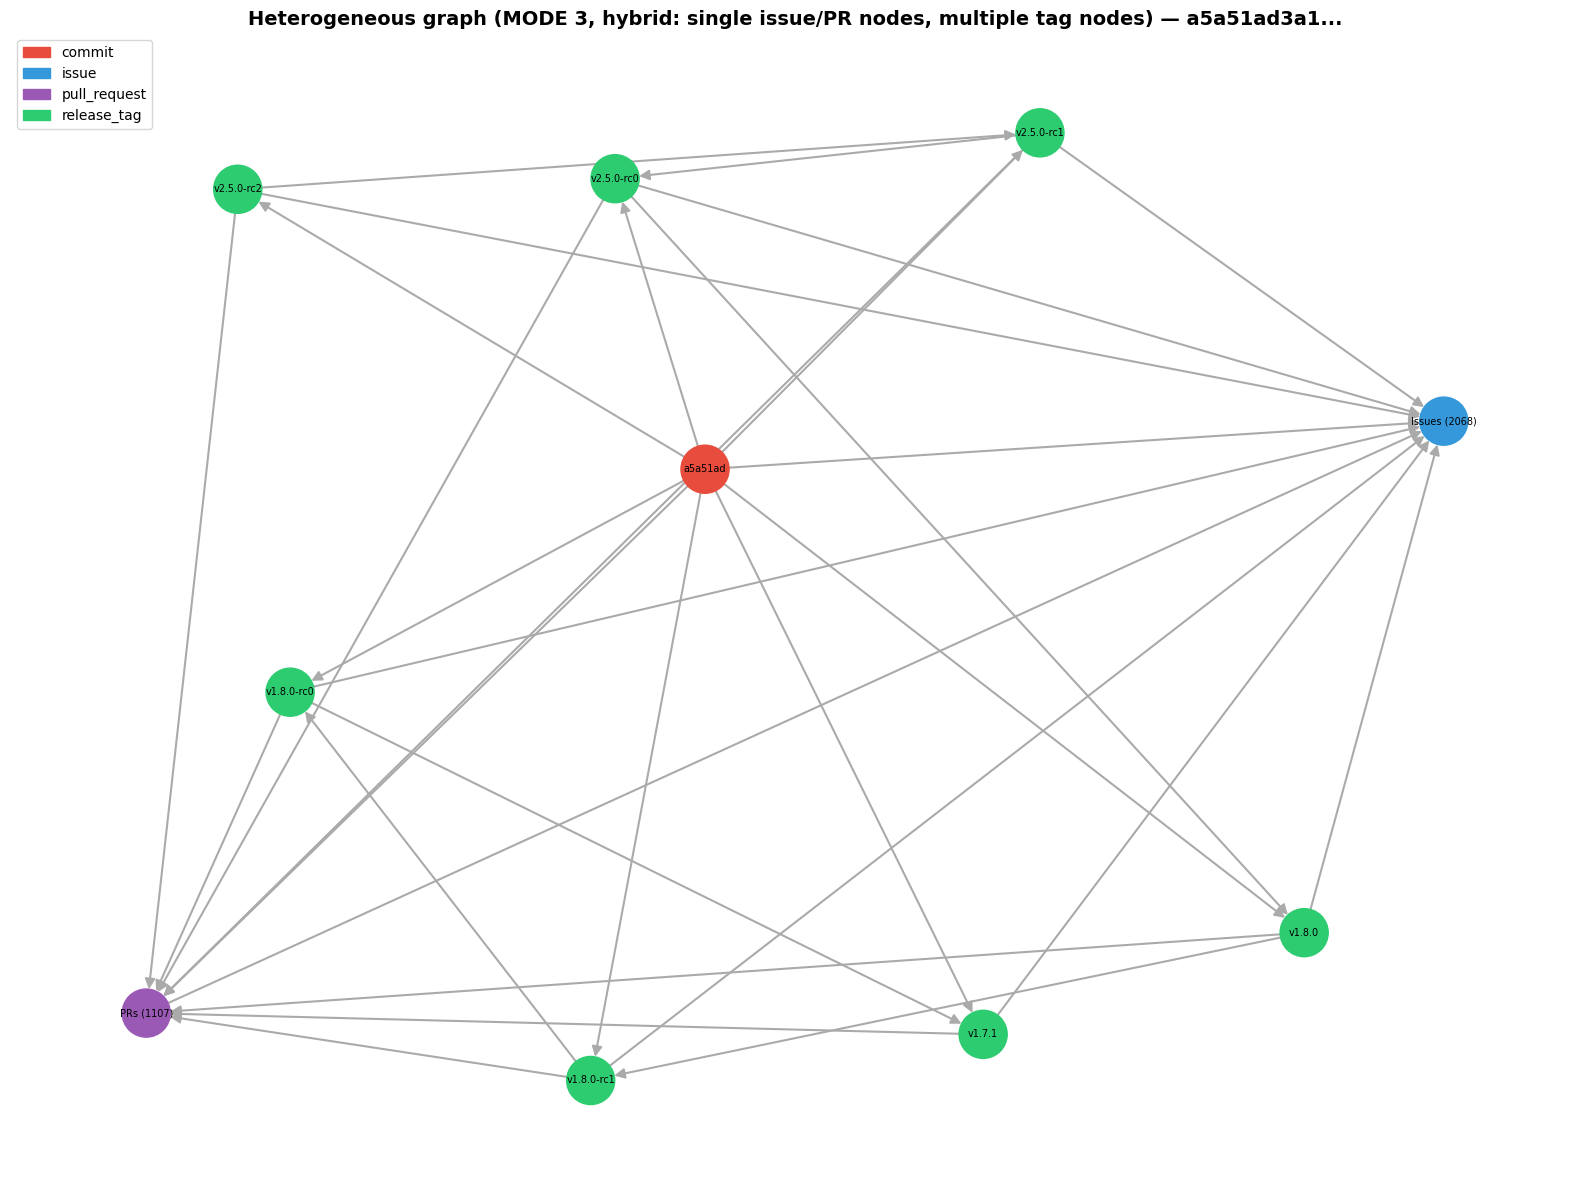


✓ Visualized 10 nodes (MODE 3: single issue/PR nodes, multiple tag nodes)


In [52]:
# NetworkX visualization with sampling

MAX_NODES_PER_TYPE = 500

# Print full graph stats before sampling
print("=== Full Graph Statistics ===")
print(f"Nodes: commit=1, issue={len(issues_unique)}, pr={len(prs_unique)}, tag={len(tags_unique)}")
print(f"Total nodes: {1 + len(issues_unique) + len(prs_unique) + len(tags_unique)}")
print(f"\nEdge counts per relation:")
for edge_type in data.edge_types:
    print(f"  {edge_type}: {data[edge_type].edge_index.shape[1]}")
print(f"\nCommit degrees:")
if len(issues_unique) > 0:
    print(f"  → issues: {data['commit', 'linked_issue', 'issue'].edge_index.shape[1]}")
if len(prs_unique) > 0:
    print(f"  → prs: {data['commit', 'linked_pr', 'pull_request'].edge_index.shape[1]}")
if len(tags_unique) > 0:
    print(f"  → tags: {data['commit', 'has_release_tag', 'release_tag'].edge_index.shape[1]}")

# Sample nodes for visualization
if MODE == 2:
    # MODE 2: single nodes only
    issues_sample = issues_unique.head(1).copy().reset_index(drop=True) if len(issues_unique) > 0 else pd.DataFrame()
    prs_sample = prs_unique.head(1).copy().reset_index(drop=True) if len(prs_unique) > 0 else pd.DataFrame()
    tags_sample = tags_unique.head(1).copy().reset_index(drop=True) if len(tags_unique) > 0 else pd.DataFrame()
elif MODE == 3:
    # MODE 3: single nodes for issues/PRs, multiple for tags
    issues_sample = issues_unique.head(1).copy().reset_index(drop=True) if len(issues_unique) > 0 else pd.DataFrame()
    prs_sample = prs_unique.head(1).copy().reset_index(drop=True) if len(prs_unique) > 0 else pd.DataFrame()
    tags_sample = tags_unique.head(MAX_NODES_PER_TYPE).copy().reset_index(drop=True)
else:
    # MODE 1, 4: sample multiple nodes
    issues_sample = issues_unique.head(MAX_NODES_PER_TYPE).copy().reset_index(drop=True)
    prs_sample = prs_unique.head(MAX_NODES_PER_TYPE).copy().reset_index(drop=True)
    tags_sample = tags_unique.head(MAX_NODES_PER_TYPE).copy().reset_index(drop=True)

# Build visualization graph
G = nx.DiGraph()
G.add_node("commit_0", node_type="commit", label=target_hash[:7])

# Add nodes
if MODE == 2:
    # MODE 2: single aggregated nodes
    if len(issues_sample) > 0:
        G.add_node("issue_0", node_type="issue", label=f"Issues ({num_issues})")
    if len(prs_sample) > 0:
        G.add_node("pr_0", node_type="pull_request", label=f"PRs ({num_prs})")
    if len(tags_sample) > 0:
        G.add_node("tag_0", node_type="release_tag", label=f"Tags ({num_tags})")
elif MODE == 3:
    # MODE 3: single aggregated nodes for issues/PRs, multiple for tags
    if len(issues_sample) > 0:
        G.add_node("issue_0", node_type="issue", label=f"Issues ({num_issues})")
    if len(prs_sample) > 0:
        G.add_node("pr_0", node_type="pull_request", label=f"PRs ({num_prs})")
    
    tag_id_col = detect_id_column(tags_sample, ['tag_name', 'name', 'tag', 'release_tag', 'id'])
    for i, row in tags_sample.iterrows():
        tag_name = row.get(tag_id_col if tag_id_col else "index", f"tag_{i}")
        G.add_node(f"tag_{i}", node_type="release_tag", label=str(tag_name)[:12])
else:
    # MODE 1, 4: individual nodes
    issue_id_col = detect_id_column(issues_sample, ['issue_id', 'id', 'number', 'issue_number'])
    for i, row in issues_sample.iterrows():
        issue_id = row.get(issue_id_col if issue_id_col else "index", i)
        G.add_node(f"issue_{i}", node_type="issue", label=f"I-{issue_id}")

    pr_id_col = detect_id_column(prs_sample, ['pull_request_id', 'pr_id', 'id', 'number', 'pull_request_number'])
    for i, row in prs_sample.iterrows():
        pr_id = row.get(pr_id_col if pr_id_col else "index", i)
        G.add_node(f"pr_{i}", node_type="pull_request", label=f"PR-{pr_id}")

    tag_id_col = detect_id_column(tags_sample, ['tag_name', 'name', 'tag', 'release_tag', 'id'])
    for i, row in tags_sample.iterrows():
        tag_name = row.get(tag_id_col if tag_id_col else "index", f"tag_{i}")
        G.add_node(f"tag_{i}", node_type="release_tag", label=str(tag_name)[:12])

# Add commit-entity edges
if MODE == 2:
    # MODE 2: single edges
    if len(issues_sample) > 0:
        G.add_edge("commit_0", "issue_0", edge_type="with_attrs")
    if len(prs_sample) > 0:
        G.add_edge("commit_0", "pr_0", edge_type="with_attrs")
    if len(tags_sample) > 0:
        G.add_edge("commit_0", "tag_0", edge_type="with_attrs")
    # PR-Issue edge
    if len(prs_sample) > 0 and len(issues_sample) > 0:
        G.add_edge("pr_0", "issue_0", edge_type="with_attrs")
    # Tag-PR edge
    if len(tags_sample) > 0 and len(prs_sample) > 0:
        G.add_edge("tag_0", "pr_0", edge_type="with_attrs")
    # Tag-Issue edge
    if len(tags_sample) > 0 and len(issues_sample) > 0:
        G.add_edge("tag_0", "issue_0", edge_type="with_attrs")
elif MODE == 3:
    # MODE 3: single edges for issues/PRs, multiple for tags
    if len(issues_sample) > 0:
        G.add_edge("commit_0", "issue_0", edge_type="with_attrs")
    if len(prs_sample) > 0:
        G.add_edge("commit_0", "pr_0", edge_type="with_attrs")
    for i in range(len(tags_sample)):
        G.add_edge("commit_0", f"tag_{i}")
    # PR-Issue edge
    if len(prs_sample) > 0 and len(issues_sample) > 0:
        G.add_edge("pr_0", "issue_0", edge_type="with_attrs")
    # Tag-PR edges (multiple tags to single PR)
    if len(tags_sample) > 0 and len(prs_sample) > 0:
        for i in range(len(tags_sample)):
            G.add_edge(f"tag_{i}", "pr_0")
    # Tag-Issue edges (multiple tags to single issue)
    if len(tags_sample) > 0 and len(issues_sample) > 0:
        for i in range(len(tags_sample)):
            G.add_edge(f"tag_{i}", "issue_0")
else:
    # MODE 1, 4: multiple edges
    for i in range(len(issues_sample)):
        G.add_edge("commit_0", f"issue_{i}")
    for i in range(len(prs_sample)):
        G.add_edge("commit_0", f"pr_{i}")
    for i in range(len(tags_sample)):
        G.add_edge("commit_0", f"tag_{i}")

# Add PR-Issue edges (if present in data)
if MODE not in [2, 3]:  # Skip for MODE 2 and 3 as we already added them above
    if ("pull_request", "references_issue", "issue") in data.edge_types:
        pr_issue_edge = data["pull_request", "references_issue", "issue"].edge_index
        for pr_idx, issue_idx in zip(pr_issue_edge[0].tolist(), pr_issue_edge[1].tolist()):
            if pr_idx < len(prs_sample) and issue_idx < len(issues_sample):
                G.add_edge(f"pr_{pr_idx}", f"issue_{issue_idx}")

# Add temporal edges (sampled) - skip for MODE 2, for MODE 3 only add tag temporal edges
if MODE not in [2, 3]:
    for edge_type in data.edge_types:
        if "next_issue" in edge_type:
            temp_edge = data[edge_type].edge_index
            for src, dst in zip(temp_edge[0].tolist(), temp_edge[1].tolist()):
                if src < len(issues_sample) and dst < len(issues_sample):
                    G.add_edge(f"issue_{src}", f"issue_{dst}", style="dotted")
        elif "next_pr" in edge_type:
            temp_edge = data[edge_type].edge_index
            for src, dst in zip(temp_edge[0].tolist(), temp_edge[1].tolist()):
                if src < len(prs_sample) and dst < len(prs_sample):
                    G.add_edge(f"pr_{src}", f"pr_{dst}", style="dotted")
        elif "next_tag" in edge_type:
            temp_edge = data[edge_type].edge_index
            for src, dst in zip(temp_edge[0].tolist(), temp_edge[1].tolist()):
                if src < len(tags_sample) and dst < len(tags_sample):
                    G.add_edge(f"tag_{src}", f"tag_{dst}", style="dotted")

elif MODE == 3:  # MODE 3: only tag temporal edges
    for edge_type in data.edge_types:
        if "next_tag" in edge_type:
            temp_edge = data[edge_type].edge_index
            for src, dst in zip(temp_edge[0].tolist(), temp_edge[1].tolist()):
                if src < len(tags_sample) and dst < len(tags_sample):
                    G.add_edge(f"tag_{src}", f"tag_{dst}", style="dotted")

# Layout & colors
color_map = {
    "commit": "#e74c3c",
    "issue": "#3498db",
    "pull_request": "#9b59b6",
    "release_tag": "#2ecc71"
}

node_colors = [color_map[G.nodes[n]["node_type"]] for n in G.nodes]
node_labels = {n: G.nodes[n]["label"] for n in G.nodes}

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

plt.figure(figsize=(16, 12))
nx.draw_networkx(G, pos=pos, labels=node_labels, node_color=node_colors,
                 node_size=1200, font_size=7, arrows=True,
                 arrowsize=15, edge_color="#aaaaaa", width=1.5)

legend = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=legend, loc="upper left", fontsize=10)
if MODE == 2:
    plt.title(f"Heterogeneous graph (MODE {MODE}, single nodes + edge attrs) — {target_hash[:10]}...", fontsize=14, fontweight="bold")
elif MODE == 3:
    plt.title(f"Heterogeneous graph (MODE {MODE}, hybrid: single issue/PR nodes, multiple tag nodes) — {target_hash[:10]}...", fontsize=14, fontweight="bold")
else:
    plt.title(f"Heterogeneous graph (MODE {MODE}, sampled) — {target_hash[:10]}...", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

if MODE == 2:
    print(f"\n✓ Visualized {G.number_of_nodes()} nodes (MODE 2: single aggregated nodes)")
elif MODE == 3:
    print(f"\n✓ Visualized {G.number_of_nodes()} nodes (MODE 3: single issue/PR nodes, multiple tag nodes)")
else:
    print(f"\n✓ Visualized {G.number_of_nodes()} nodes (sampled from full graph)")

In [53]:
# Sanity checks

# Assert exactly 1 commit node
assert data["commit"].x.shape[0] == 1, f"Expected 1 commit node, got {data['commit'].x.shape[0]}"

# Check edge counts match node counts
num_issues = len(issues_unique)
num_prs = len(prs_unique)
num_tags = len(tags_unique)

if MODE == 2:  # MODE 2: single nodes, single edges
    if num_issues > 0:
        assert data["issue"].x.shape[0] == 1, f"MODE 2: Expected 1 issue node, got {data['issue'].x.shape[0]}"
        assert data["commit", "linked_issue", "issue"].edge_index.shape[1] == 1, "MODE 2: Expected 1 commit-issue edge"
        assert data["issue", "issue_of", "commit"].edge_index.shape[1] == 1, "MODE 2: Expected 1 issue-commit edge"
    
    if num_prs > 0:
        assert data["pull_request"].x.shape[0] == 1, f"MODE 2: Expected 1 PR node, got {data['pull_request'].x.shape[0]}"
        assert data["commit", "linked_pr", "pull_request"].edge_index.shape[1] == 1, "MODE 2: Expected 1 commit-PR edge"
        assert data["pull_request", "pr_of", "commit"].edge_index.shape[1] == 1, "MODE 2: Expected 1 PR-commit edge"
    
    if num_tags > 0:
        assert data["release_tag"].x.shape[0] == 1, f"MODE 2: Expected 1 tag node, got {data['release_tag'].x.shape[0]}"
        assert data["commit", "has_release_tag", "release_tag"].edge_index.shape[1] == 1, "MODE 2: Expected 1 commit-tag edge"
        assert data["release_tag", "tag_of", "commit"].edge_index.shape[1] == 1, "MODE 2: Expected 1 tag-commit edge"
    
    if num_prs > 0 and num_issues > 0:
        if ("pull_request", "references_issue", "issue") in data.edge_types:
            assert data["pull_request", "references_issue", "issue"].edge_index.shape[1] == 1, "MODE 2: Expected 1 PR-issue edge"
    
    if num_tags > 0 and num_prs > 0:
        if ("release_tag", "affects_pr", "pull_request") in data.edge_types:
            assert data["release_tag", "affects_pr", "pull_request"].edge_index.shape[1] == 1, "MODE 2: Expected 1 tag-PR edge"
    
    if num_tags > 0 and num_issues > 0:
        if ("release_tag", "affects_issue", "issue") in data.edge_types:
            assert data["release_tag", "affects_issue", "issue"].edge_index.shape[1] == 1, "MODE 2: Expected 1 tag-issue edge"

elif MODE == 3:  # MODE 3: single nodes for issues/PRs, multiple nodes for tags
    if num_issues > 0:
        assert data["issue"].x.shape[0] == 1, f"MODE 3: Expected 1 issue node, got {data['issue'].x.shape[0]}"
        assert data["commit", "linked_issue", "issue"].edge_index.shape[1] == 1, "MODE 3: Expected 1 commit-issue edge"
        assert data["issue", "issue_of", "commit"].edge_index.shape[1] == 1, "MODE 3: Expected 1 issue-commit edge"
    
    if num_prs > 0:
        assert data["pull_request"].x.shape[0] == 1, f"MODE 3: Expected 1 PR node, got {data['pull_request'].x.shape[0]}"
        assert data["commit", "linked_pr", "pull_request"].edge_index.shape[1] == 1, "MODE 3: Expected 1 commit-PR edge"
        assert data["pull_request", "pr_of", "commit"].edge_index.shape[1] == 1, "MODE 3: Expected 1 PR-commit edge"
    
    if num_tags > 0:
        assert data["release_tag"].x.shape[0] == num_tags, f"MODE 3: Expected {num_tags} tag nodes, got {data['release_tag'].x.shape[0]}"
        assert data["commit", "has_release_tag", "release_tag"].edge_index.shape[1] == num_tags, f"MODE 3: Expected {num_tags} commit-tag edges"
        assert data["release_tag", "tag_of", "commit"].edge_index.shape[1] == num_tags, f"MODE 3: Expected {num_tags} tag-commit edges"
    
    if num_prs > 0 and num_issues > 0:
        if ("pull_request", "references_issue", "issue") in data.edge_types:
            assert data["pull_request", "references_issue", "issue"].edge_index.shape[1] == 1, "MODE 3: Expected 1 PR-issue edge"
    
    if num_tags > 0 and num_prs > 0:
        if ("release_tag", "affects_pr", "pull_request") in data.edge_types:
            assert data["release_tag", "affects_pr", "pull_request"].edge_index.shape[1] == num_tags, f"MODE 3: Expected {num_tags} tag-PR edges"
    
    if num_tags > 0 and num_issues > 0:
        if ("release_tag", "affects_issue", "issue") in data.edge_types:
            assert data["release_tag", "affects_issue", "issue"].edge_index.shape[1] == num_tags, f"MODE 3: Expected {num_tags} tag-issue edges"

else:  # MODE 1, 4: multiple nodes, multiple edges
    if num_issues > 0:
        assert data["commit", "linked_issue", "issue"].edge_index.shape[1] == num_issues
        assert data["issue", "issue_of", "commit"].edge_index.shape[1] == num_issues
    
    if num_prs > 0:
        assert data["commit", "linked_pr", "pull_request"].edge_index.shape[1] == num_prs
        assert data["pull_request", "pr_of", "commit"].edge_index.shape[1] == num_prs
    
    if num_tags > 0:
        assert data["commit", "has_release_tag", "release_tag"].edge_index.shape[1] == num_tags
        assert data["release_tag", "tag_of", "commit"].edge_index.shape[1] == num_tags

print("✓ Sanity checks passed")
print(f"\nCommit label (y_binary): {data['commit'].y[0].item()}")

if MODE == 2:
    # MODE 2 has single nodes
    actual_node_count = 1 + (1 if num_issues > 0 else 0) + (1 if num_prs > 0 else 0) + (1 if num_tags > 0 else 0)
    print(f"Total nodes (MODE 2 - single nodes): 1 commit + {1 if num_issues > 0 else 0} issue + {1 if num_prs > 0 else 0} PR + {1 if num_tags > 0 else 0} tag = {actual_node_count}")
    print(f"Raw entity counts: {num_issues} issues, {num_prs} PRs, {num_tags} tags in data")
elif MODE == 3:
    # MODE 3 has single nodes for issues/PRs, multiple for tags
    actual_node_count = 1 + (1 if num_issues > 0 else 0) + (1 if num_prs > 0 else 0) + num_tags
    print(f"Total nodes (MODE 3 - hybrid): 1 commit + {1 if num_issues > 0 else 0} issue + {1 if num_prs > 0 else 0} PR + {num_tags} tags = {actual_node_count}")
    print(f"Raw entity counts: {num_issues} issues, {num_prs} PRs, {num_tags} tags in data")
else:
    print(f"Total unique nodes: 1 commit + {num_issues} issues + {num_prs} PRs + {num_tags} tags = {1 + num_issues + num_prs + num_tags}")


# Count total edges
total_edges = sum([data[et].edge_index.shape[1] for et in data.edge_types])
print(f"Total edges (all relations): {total_edges}")

# Check edge attributes for MODE 2 and 3
if MODE in [2, 3]:
    print(f"\n=== Edge Attribute Checks (MODE {MODE}) ===")
    for edge_type in data.edge_types:
        if hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None:
            num_edges = data[edge_type].edge_index.shape[1]
            attr_shape = data[edge_type].edge_attr.shape
            print(f"  {edge_type}: {num_edges} edges, edge_attr shape {attr_shape}")
            assert attr_shape[0] == num_edges, f"Edge count mismatch for {edge_type}"


✓ Sanity checks passed

Commit label (y_binary): 1
Total nodes (MODE 3 - hybrid): 1 commit + 1 issue + 1 PR + 7 tags = 10
Raw entity counts: 2068 issues, 1107 PRs, 7 tags in data
Total edges (all relations): 60

=== Edge Attribute Checks (MODE 3) ===
  ('commit', 'linked_issue', 'issue'): 1 edges, edge_attr shape torch.Size([1, 1])
  ('issue', 'issue_of', 'commit'): 1 edges, edge_attr shape torch.Size([1, 1])
  ('commit', 'linked_pr', 'pull_request'): 1 edges, edge_attr shape torch.Size([1, 1])
  ('pull_request', 'pr_of', 'commit'): 1 edges, edge_attr shape torch.Size([1, 1])
  ('pull_request', 'references_issue', 'issue'): 1 edges, edge_attr shape torch.Size([1, 2])
  ('issue', 'referenced_by_pr', 'pull_request'): 1 edges, edge_attr shape torch.Size([1, 2])


In [54]:
# Results summary

print("="*70)
print(f"GRAPH CONSTRUCTION SUMMARY — MODE {MODE}")
print("="*70)

mode_descriptions = {
    1: "Only raw data (no engineered commit features)",
    2: "Only manually engineered features (single nodes with edge attributes)",
    3: "Hybrid: tags as raw (multiple nodes), issues/PRs as engineered (single nodes)",
    4: "Engineered features + raw release tags only"
}
print(f"\nMode: {mode_descriptions.get(MODE, 'Unknown')}")
print(f"Target commit: {target_hash[:16]}...")
print(f"Commit label (y_binary): {data['commit'].y[0].item()}")

print(f"\n--- Node Counts ---")
print(f"  commit: 1")
if MODE == 2:
    print(f"  issue: {1 if num_issues > 0 else 0} (single aggregated node)")
    print(f"  pull_request: {1 if num_prs > 0 else 0} (single aggregated node)")
    print(f"  release_tag: {1 if num_tags > 0 else 0} (single aggregated node)")
    actual_node_count = 1 + (1 if num_issues > 0 else 0) + (1 if num_prs > 0 else 0) + (1 if num_tags > 0 else 0)
    print(f"  TOTAL: {actual_node_count}")
    print(f"  (Based on {num_issues} raw issues, {num_prs} raw PRs, {num_tags} raw tags)")
elif MODE == 3:
    print(f"  issue: {1 if num_issues > 0 else 0} (single aggregated node)")
    print(f"  pull_request: {1 if num_prs > 0 else 0} (single aggregated node)")
    print(f"  release_tag: {num_tags} (multiple raw nodes)")
    actual_node_count = 1 + (1 if num_issues > 0 else 0) + (1 if num_prs > 0 else 0) + num_tags
    print(f"  TOTAL: {actual_node_count}")
    print(f"  (Based on {num_issues} raw issues, {num_prs} raw PRs)")
else:
    print(f"  issue: {len(issues_unique)}")
    print(f"  pull_request: {len(prs_unique)}")
    print(f"  release_tag: {len(tags_unique)}")
    print(f"  TOTAL: {1 + len(issues_unique) + len(prs_unique) + len(tags_unique)}")

print(f"\n--- Edge Counts per Relation ---")
for edge_type in sorted(data.edge_types):
    count = data[edge_type].edge_index.shape[1]
    if hasattr(data[edge_type], 'edge_attr') and data[edge_type].edge_attr is not None:
        attr_shape = data[edge_type].edge_attr.shape
        print(f"  {edge_type}: {count} edges (edge_attr: {attr_shape})")
    else:
        print(f"  {edge_type}: {count}")


print(f"\n--- Feature Dimensions ---")
print(f"  commit.x: {data['commit'].x.shape} — {len(feature_info['commit'])} features")
if len(issues_unique) > 0:
    print(f"  issue.x: {data['issue'].x.shape} — {len(feature_info['issue'])} features")
if len(prs_unique) > 0:
    print(f"  pull_request.x: {data['pull_request'].x.shape} — {len(feature_info['pull_request'])} features")
if len(tags_unique) > 0:
    print(f"  release_tag.x: {data['release_tag'].x.shape} — {len(feature_info['release_tag'])} features")

print(f"\n--- Selected Feature Columns (first 8 shown) ---")
for node_type in ["commit", "issue", "pull_request", "release_tag"]:
    cols = feature_info[node_type]
    if cols:
        print(f"  {node_type}: {cols[:8]}{'...' if len(cols) > 8 else ''}")

if "edge_features" in feature_info:
    print(f"\n--- Edge Feature Columns (MODE {MODE}) ---")
    for edge_type, cols in feature_info["edge_features"].items():
        if cols:
            print(f"  {edge_type}: {cols}")

print("\n" + "="*70)

GRAPH CONSTRUCTION SUMMARY — MODE 3

Mode: Hybrid: tags as raw (multiple nodes), issues/PRs as engineered (single nodes)
Target commit: a5a51ad3a1200e2e...
Commit label (y_binary): 1

--- Node Counts ---
  commit: 1
  issue: 1 (single aggregated node)
  pull_request: 1 (single aggregated node)
  release_tag: 7 (multiple raw nodes)
  TOTAL: 10
  (Based on 2068 raw issues, 1107 raw PRs)

--- Edge Counts per Relation ---
  ('commit', 'has_release_tag', 'release_tag'): 7
  ('commit', 'linked_issue', 'issue'): 1 edges (edge_attr: torch.Size([1, 1]))
  ('commit', 'linked_pr', 'pull_request'): 1 edges (edge_attr: torch.Size([1, 1]))
  ('issue', 'in_release', 'release_tag'): 7
  ('issue', 'issue_of', 'commit'): 1 edges (edge_attr: torch.Size([1, 1]))
  ('issue', 'referenced_by_pr', 'pull_request'): 1 edges (edge_attr: torch.Size([1, 2]))
  ('pull_request', 'in_release', 'release_tag'): 7
  ('pull_request', 'pr_of', 'commit'): 1 edges (edge_attr: torch.Size([1, 1]))
  ('pull_request', 'referenc